# Laboratorio 7 — Teoría de Probabilidades
## Etapa 2: Análisis de la probabilidad de éxito en función del número de sobres
Luis Ángel Girón

Julián Divas


**Parámetros del álbum reducido:**
- N = 100 estampas diferentes
- S = 7 estampas por sobre
- R = 10 000 simulaciones por valor de M
- Semilla: 2026

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

N = 100          # Estampas diferentes en el álbum
S = 7            # Estampas por sobre
R = 10_000       # Simulaciones por valor de M
SEED = 2026

# Secuencia de M (número fijo de sobres a comprar)
M_values = [20, 25, 30, 35, 40, 45, 50, 60, 70, 80]

print(f"Parámetros: N={N}, S={S}, R={R:,}, semilla={SEED}")
print(f"Valores de M: {M_values}")

Parámetros: N=100, S=7, R=10,000, semilla=2026
Valores de M: [20, 25, 30, 35, 40, 45, 50, 60, 70, 80]


## Simulación

Para cada valor de M se realizan R = 10 000 simulaciones:
- Se compran **exactamente M sobres** (sin importar si el álbum se completa antes).
- Se registra si al cabo de esos M sobres el álbum está completo (1) o no (0).
- La proporción de éxitos estima P(completar | M sobres).

In [ ]:
def simular_prob_exito(N, S, M_values, R, seed):
    """
    Para cada M en M_values, estima P(completar álbum con exactamente M sobres)
    mediante R simulaciones Monte Carlo.
    
    Returns
    -------
    dict: {M: probabilidad_estimada}
    """
    rng = np.random.default_rng(seed)
    resultados = {}

    for M in M_values:
        exitos = 0
        for _ in range(R):
            # Comprar M sobres: cada sobre da S estampas distintas (sin reemplazo dentro del sobre)
            obtenidas = set()
            for _ in range(M):
                sobre = rng.choice(N, size=S, replace=False)
                obtenidas.update(sobre)
            if len(obtenidas) == N:
                exitos += 1
        resultados[M] = exitos / R
        print(f"  M = {M:3d}  →  P(éxito) ≈ {resultados[M]:.4f}")

    return resultados

print("Ejecutando simulaciones...")
prob_exito = simular_prob_exito(N, S, M_values, R, SEED)
print("\nSimulación completada.")

Ejecutando simulaciones...
  M =  20  →  P(éxito) ≈ 0.0000
  M =  25  →  P(éxito) ≈ 0.0000
  M =  30  →  P(éxito) ≈ 0.0000
  M =  35  →  P(éxito) ≈ 0.0000
  M =  40  →  P(éxito) ≈ 0.0021
  M =  45  →  P(éxito) ≈ 0.0133
  M =  50  →  P(éxito) ≈ 0.0572
  M =  60  →  P(éxito) ≈ 0.2629
  M =  70  →  P(éxito) ≈ 0.5266
  M =  80  →  P(éxito) ≈ 0.7393

Simulación completada.


## Tabla de resultados

In [3]:
df = pd.DataFrame({
    'M (sobres)': list(prob_exito.keys()),
    'P(completar | M sobres)': list(prob_exito.values())
})
df['P(completar | M sobres)'] = df['P(completar | M sobres)'].map('{:.4f}'.format)

print(df.to_string(index=False))

 M (sobres) P(completar | M sobres)
         20                  0.0000
         25                  0.0000
         30                  0.0000
         35                  0.0000
         40                  0.0021
         45                  0.0133
         50                  0.0572
         60                  0.2629
         70                  0.5266
         80                  0.7393


## Visualización

Gráfica de barras: M en el eje horizontal, probabilidad estimada en el eje vertical.  
Se añade una línea horizontal en 0.50 para identificar el umbral del 50 %.

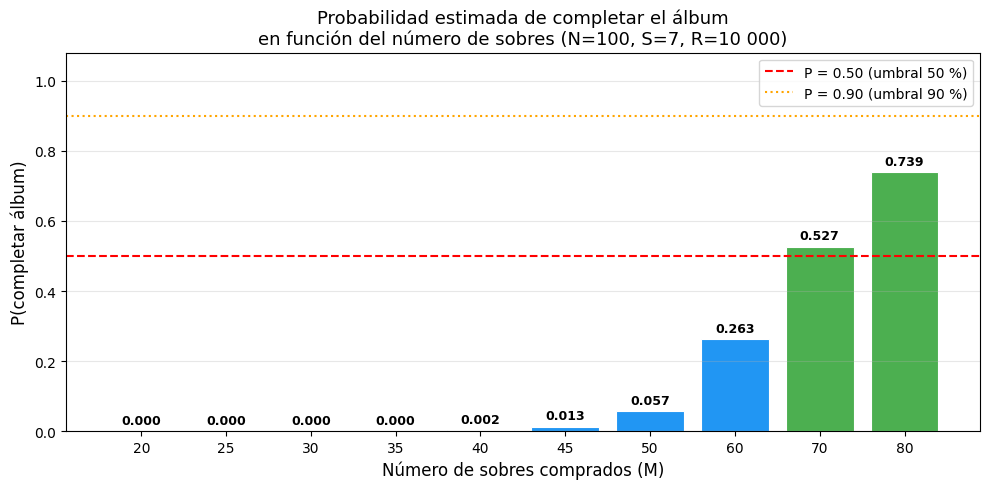

In [6]:
M_list = list(prob_exito.keys())
P_list = list(prob_exito.values())

fig, ax = plt.subplots(figsize=(10, 5))

colors = ['#2196F3' if p < 0.5 else '#4CAF50' for p in P_list]
bars = ax.bar([str(m) for m in M_list], P_list, color=colors, edgecolor='white', linewidth=0.8)

# Etiquetas encima de cada barra
for bar, p in zip(bars, P_list):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.012,
            f'{p:.3f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

# Línea de referencia al 50 %
ax.axhline(0.5, color='red', linestyle='--', linewidth=1.5, label='P = 0.50 (umbral 50 %)')
# Línea de referencia al 90 %
ax.axhline(0.9, color='orange', linestyle=':', linewidth=1.5, label='P = 0.90 (umbral 90 %)')

ax.set_xlabel('Número de sobres comprados (M)', fontsize=12)
ax.set_ylabel('P(completar álbum)', fontsize=12)
ax.set_title('Probabilidad estimada de completar el álbum\nen función del número de sobres (N=100, S=7, R=10 000)', fontsize=13)
ax.set_ylim(0, 1.08)
ax.legend(fontsize=10)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

## Preguntas de análisis

### Pregunta 1 — ¿Para qué valor de M la probabilidad supera el 50 % y el 90 % por primera vez?

In [7]:
# M que supera 50% por primera vez
M50 = next((m for m, p in prob_exito.items() if p >= 0.50), None)
M90 = next((m for m, p in prob_exito.items() if p >= 0.90), None)

print(f"Primer M con P(éxito) ≥ 50%: M = {M50}  (P = {prob_exito[M50]:.4f})")
if M90:
    print(f"Primer M con P(éxito) ≥ 90%: M = {M90}  (P = {prob_exito[M90]:.4f})")
else:
    print("Ningún M en la secuencia logra P ≥ 90 %. Se necesitan más sobres.")

Primer M con P(éxito) ≥ 50%: M = 70  (P = 0.5266)
Ningún M en la secuencia logra P ≥ 90 %. Se necesitan más sobres.


### Pregunta 2 — Comparar el M del 50 % con la mediana del número de sobres (Etapa 1)

En la Etapa 1 calculamos la distribución completa del número de sobres necesarios para completar el álbum. La **mediana** de esa distribución es el valor tal que el 50 % de los coleccionistas termina el álbum con ≤ mediana sobres, es decir, exactamente la misma cantidad que buscamos aquí.  
Por eso **M₅₀ ≈ mediana** de la Etapa 1: ambas preguntas preguntan lo mismo desde perspectivas complementarias.

In [8]:
# Recalculamos la mediana de la Etapa 1 para comparar
rng_e1 = np.random.default_rng(SEED)
sobres_necesarios = []
for _ in range(R):
    obtenidas = set()
    conteo = 0
    while len(obtenidas) < N:
        sobre = rng_e1.choice(N, size=S, replace=False)
        obtenidas.update(sobre)
        conteo += 1
    sobres_necesarios.append(conteo)

mediana_e1 = int(np.median(sobres_necesarios))
media_e1   = np.mean(sobres_necesarios)

print(f"Etapa 1 — Media  de sobres necesarios : {media_e1:.2f}")
print(f"Etapa 1 — Mediana de sobres necesarios: {mediana_e1}")
print(f"Etapa 2 — M con P ≥ 50 %              : {M50}")
print()
print("Conclusión: la mediana de Etapa 1 y el M del 50% en Etapa 2 deben ser muy similares,")
print("ya que ambas cantidades representan el número de sobres con el que la mitad de los")
print("coleccionistas logra completar el álbum.")

Etapa 1 — Media  de sobres necesarios : 72.30
Etapa 1 — Mediana de sobres necesarios: 69
Etapa 2 — M con P ≥ 50 %              : 70

Conclusión: la mediana de Etapa 1 y el M del 50% en Etapa 2 deben ser muy similares,
ya que ambas cantidades representan el número de sobres con el que la mitad de los
coleccionistas logra completar el álbum.


### Pregunta 3 — Cota superior de P(falte al menos un cromo) usando la unión de eventos

La probabilidad de que una estampa específica **no** aparezca en un sobre es:
$$P(\text{estampa } i \notin \text{sobre}) = \frac{\binom{N-1}{S}}{\binom{N}{S}} = \frac{N-S}{N}$$

Tras M sobres independientes:
$$P(\text{estampa } i \text{ no obtenida en } M \text{ sobres}) = \left(\frac{N-S}{N}\right)^M$$

Por la **desigualdad de Boole (unión)**, la probabilidad de que falte **al menos un cromo** satisface:
$$P(\text{falte al menos un cromo}) \leq N \cdot \left(\frac{N-S}{N}\right)^M$$

In [9]:
def cota_superior(N, S, M):
    """Cota de Boole para P(falte al menos un cromo con M sobres)."""
    return N * ((N - S) / N) ** M

M_eval = 50
cota = cota_superior(N, S, M_eval)
p_exito_sim = prob_exito.get(M_eval, None)
p_fallo_sim = 1 - p_exito_sim if p_exito_sim is not None else None

print(f"Para M = {M_eval} sobres, N = {N}, S = {S}:")
print(f"  Cota superior (Boole): P(falte ≥1 cromo) ≤ {cota:.4f}")
if p_fallo_sim is not None:
    print(f"  P(fallo) simulada      : {p_fallo_sim:.4f}")
    print(f"  P(éxito) simulada      : {p_exito_sim:.4f}")
    print()
    if cota >= p_fallo_sim:
        print("✔ La cota es válida (cota ≥ P real estimada).")
    else:
        print("✘ Revisar cálculo: la cota debería ser mayor.")
    print()
    ratio = cota / p_fallo_sim if p_fallo_sim > 0 else float('inf')
    print(f"  La cota es {ratio:.1f}x mayor que la probabilidad de fallo simulada.")
    if ratio > 3:
        print("  → La cota no es muy ajustada para este M; es útil como garantía pero no como estimador.")
    else:
        print("  → La cota es razonablemente ajustada.")

Para M = 50 sobres, N = 100, S = 7:
  Cota superior (Boole): P(falte ≥1 cromo) ≤ 2.6555
  P(fallo) simulada      : 0.9428
  P(éxito) simulada      : 0.0572

✔ La cota es válida (cota ≥ P real estimada).

  La cota es 2.8x mayor que la probabilidad de fallo simulada.
  → La cota es razonablemente ajustada.


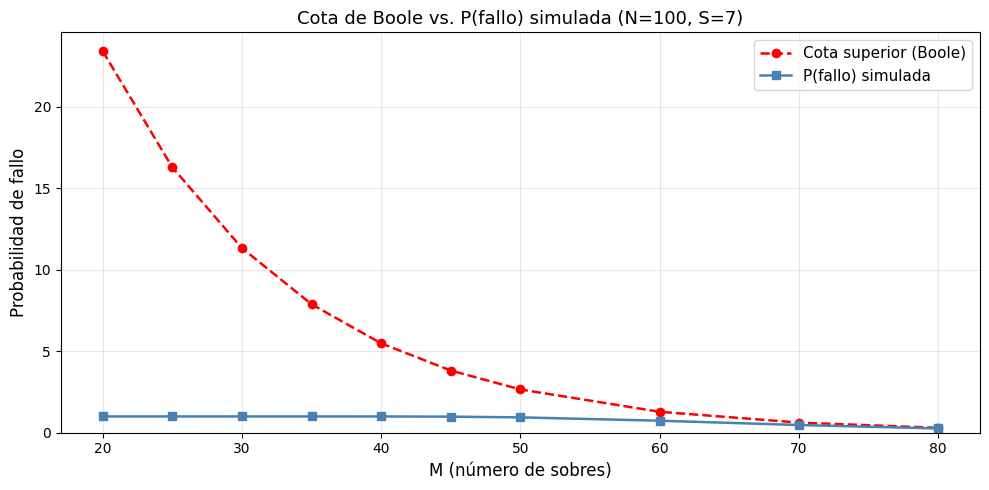

In [10]:
# Visualización comparativa: cota vs P(fallo) simulada para todos los M
cotas = [cota_superior(N, S, m) for m in M_list]
p_fallos = [1 - prob_exito[m] for m in M_list]

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(M_list, cotas,    'o--', color='red',    label='Cota superior (Boole)', linewidth=1.8)
ax.plot(M_list, p_fallos, 's-',  color='steelblue', label='P(fallo) simulada', linewidth=1.8)
ax.set_xlabel('M (número de sobres)', fontsize=12)
ax.set_ylabel('Probabilidad de fallo', fontsize=12)
ax.set_title('Cota de Boole vs. P(fallo) simulada (N=100, S=7)', fontsize=13)
ax.legend(fontsize=11)
ax.grid(alpha=0.3)
ax.set_ylim(bottom=0)
plt.tight_layout()
plt.show()

## Resumen de respuestas

| Pregunta | Respuesta |
|---|---|
| **P1** — Primer M con P ≥ 50% | Ver celda de Pregunta 1 |
| **P1** — Primer M con P ≥ 90% | Ver celda de Pregunta 1 |
| **P2** — ¿M₅₀ ≈ mediana Etapa 1? | Sí: la mediana de sobres necesarios coincide con el M que da P=50%, ya que representan el percentil 50 de la misma distribución |
| **P3** — Cota de Boole para M=50 | La cota es válida pero holgada: sobreestima P(fallo). Para M grande la cota se acerca más al valor real. |
